# Atividade Avaliativa — Deep Agent de Planejamento de Viagem

Esta avaliação é um notebook único, com **seis tarefas encadeadas**. Cada tarefa constrói uma peça de um
*deep agent* que planeja uma viagem, e as peças se combinam na última tarefa.

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a> 

Você vai implementar:

- as **tools** locais de cálculo;
- a **integração com um servidor MCP** de clima e geolocalização (cliente, não o servidor);
- o **sistema de arquivos**, a **skill** e o **coordenador** com lista de tarefas;
- dois **subagentes**, cada um com uma técnica de planejamento diferente;
- a **integração** de tudo, com traço de execução.

Ao final, há uma seção de análise crítica, que também será avaliada (assim como uma tarefa de implementação).


## 0.1 Como esta avaliação funciona

**Encadeamento.** As tarefas dependem umas das outras: a Tarefa 3 usa o estado definido na Tarefa 2, os
subagentes das Tarefas 4 e 5 são delegados pelo coordenador da Tarefa 3, e a Tarefa 6 integra tudo. Resolva
na ordem.

**O que é avaliado.** Não há dataset e não se avalia a qualidade da viagem produzida. Avalia-se se o
**mecanismo** funciona: as funções devolvem o esperado, o subagente roda em contexto isolado, o arquivo é
gravado e relido, o plano é atualizado. E, na última seção, se você sabe justificar as escolhas.

**Células de verificação.** Depois de cada tarefa há uma célula com `assert` e checagens. Ela imprime `[OK]`
ou `[FALHOU]` para cada critério. Rode antes de seguir.

**Regras.** Consulta livre a notebooks, documentação e material da disciplina. Deixe todas as saídas salvas
no notebook entregue.


## 0.2 Pesos

| Tarefa | O que constrói (objetivo) | Peso |
|---|---|---|
| 1 | Tools locais de cálculo | 10% |
| 2 | Integração com servidor MCP (clima e geolocalização) | 10% |
| 3 | Sistema de arquivos, skill e coordenador com `write_todos` | 20% |
| 4 | Subagente de Orçamento — **ReWOO** | 25% |
| 5 | Subagente de Destino — **Tree of Thoughts** | 25% |
| 6 | Integração  | 10% |


## 0.3 Submissão

* Esta tarefa pode ser realizada individual ou em dupla.
* Apenas **um arquivo por dupla** deve ser submetido.
* Você deve entregar um arquivo do Jupyter Notebook (`.ipynb`), executado do início ao fim, com todas as
  saídas salvas, subdividido conforme as tarefas propostas nesta atividade (Tarefas 1 a 6, mais a análise
  crítica e a especificação escrita da Seção 9). Ver a Seção "8. Checklist de entrega" ao final.
* Junto do notebook, entregue também os arquivos auxiliares gerados durante a resolução — em particular
  `skills/montar-dia-de-roteiro.md` — e o arquivo de configuração do servidor MCP utilizado na Tarefa 2, se
  aplicável. Empacote tudo em um único `.zip`.
* Apenas **um integrante da equipe** deve submeter o arquivo com a solução documentada via Classroom. Nenhum outro canal de entrega será atendido. Respeitar a data e hora limite da entrega conforme descrição no Classroom.
* O arquivo (ou o `.zip`) deve ser nomeado da seguinte forma:

`atividade-deepagent-viagem-<nome_dos_integrantes>.ipynb`

(ou `.zip`, se houver arquivos auxiliares — mantendo o mesmo padrão de nome para o arquivo compactado).


## 0.4 Preenchimento do notebook resposta

* O notebook já vem estruturado por tarefa: enunciado (markdown) → célula(s) de solução → célula de
  verificação. **Não apague, mova ou renomeie** as células de enunciado nem as de verificação.
* Dentro do bloco de cada tarefa, você pode **adicionar quantas células de código ou markdown quiser**
  (funções auxiliares, testes intermediários, explicações do raciocínio, `print`s de depuração etc.). O
  único requisito é que, ao final do bloco da tarefa — antes da célula de verificação correspondente —
  todos os nomes exigidos (funções, classes, variáveis como `coordenador`, `subagente_orcamento`, `T`, ...)
  estejam definidos exatamente com o nome usado nas checagens (`verificar(...)`), pois é isso que a
  verificação importa do namespace do notebook.
* Pode reorganizar livremente as células **dentro do bloco de uma mesma tarefa**, mas não mova células de
  solução para o bloco de outra tarefa — a numeração e o encadeamento dependem da ordem das tarefas.
* Se precisar de uma biblioteca além das já instaladas, adicione-a na célula `%pip install` da Seção 0.7
  (Preparação do ambiente), não em uma célula solta no meio de uma tarefa.
* Células de texto explicando decisões de projeto são bem-vindas, mas não substituem código funcional —
  o que é avaliado é o comportamento verificado pela célula `verificar(...)` de cada tarefa.
* Antes de entregar, rode o notebook do início ao fim em uma sessão limpa (**Kernel/Runtime → Restart and
  Run All**) para garantir que ele funciona na ordem em que será corrigido, e deixe todas as saídas salvas.


## 0.5 O cenário

O cenário é **fixo e igual para todos**. Não altere os valores — as verificações dependem deles.

> **Viagem:** duas pessoas saindo de São Paulo (GRU), de **12 a 19 de outubro de 2026**.
> **Orçamento total:** R$ 12.000,00, incluindo passagens, hospedagem, transporte local e alimentação.
> **Interesses:** gastronomia, museus e natureza urbana.
> **Restrição 1:** um dos viajantes tem mobilidade reduzida — trajetos a pé acima de 2 km e atrações sem
> acessibilidade devem ser evitados.
> **Restrição 2:** no dia **15 de outubro** há um feriado local no destino, com a maior parte dos museus e
> comércio fechados.
> **Destinos candidatos:** Buenos Aires, Santiago e Montevidéu. O agente deve escolher **um**.

Os candidatos são fixos de propósito: isso torna a árvore de decisão da Tarefa 6 comparável entre todos.

## 0.6 Mapa das tarefas

1. Tools locais de cálculo.
2. Integração com um servidor MCP de clima e geolocalização (Open-Meteo / Nominatim).
3. Sistema de arquivos, skill e coordenador.
4. Subagente de Orçamento com ReWOO.
5. Subagente de Destino com Tree of Thoughts.
6. Integração e traço de execução.
7. Análise crítica.
8. Especificação escrita (Plan-and-Execute e Reflection).

> As Seções 7 e 8 (análise crítica e especificação escrita) são referenciadas no checklist de entrega, mas
> ainda não têm células próprias neste notebook — adicione-as antes de aplicar esta avaliação, com as
> perguntas específicas que você quer que os alunos respondam.


---

## 0.7 Preparação do ambiente

**Não modifique as células desta seção.** Apenas execute-as na ordem — elas definem funções auxiliares e
utilitários de verificação usados por todas as tarefas.


In [43]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langchain langchain-core langgraph langchain-openai python-dotenv pydantic rich
%pip install -U mcp langchain-mcp-adapters httpx
%pip install -U deepagents

Note: you may need to restart the kernel to use updated packages.
  Using cached opentelemetry_api-1.44.0-py3-none-any.whl.metadata (1.4 kB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [44]:
from __future__ import annotations

import asyncio
import json
import os
from datetime import date, datetime, timedelta
from typing import Annotated, Any, Dict, List, Literal, Optional, TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain.tools import tool as tool_decorator
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import InjectedToolCallId

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

from IPython.display import Image, display
from rich import print
from rich.markdown import Markdown

In [45]:
def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_json(value: Any) -> None:
    print(json.dumps(value, ensure_ascii=False, indent=2, default=str))


def print_messages(messages: List[BaseMessage]) -> None:
    for index, message in enumerate(messages):
        print(f"\nMensagem {index} — {message.__class__.__name__}")
        if isinstance(message, AIMessage) and message.tool_calls:
            print("tool_calls:", [c["name"] for c in message.tool_calls])
        else:
            conteudo = str(message.content)
            print(conteudo[:300] + (" [...]" if len(conteudo) > 300 else ""))


def contar_tokens_aproximado(messages: List[BaseMessage]) -> int:
    total = 0
    for m in messages:
        total += len(str(m.content))
        if isinstance(m, AIMessage) and m.tool_calls:
            total += len(json.dumps(m.tool_calls, ensure_ascii=False))
    return total // 4


_RESULTADOS_VERIFICACAO: Dict[str, List[bool]] = {}


def verificar(tarefa: str, criterio: str, condicao: bool, detalhe: str = "") -> None:
    """Registra e imprime o resultado de um critério de verificação."""
    _RESULTADOS_VERIFICACAO.setdefault(tarefa, []).append(bool(condicao))
    marca = "[OK]     " if condicao else "[FALHOU] "
    print(f"{marca}{criterio}" + (f"  ->  {detalhe}" if detalhe and not condicao else ""))


def resumo_verificacoes() -> None:
    print("\n=== RESUMO DAS VERIFICAÇÕES ===")
    for tarefa, resultados in _RESULTADOS_VERIFICACAO.items():
        print(f"{tarefa:34} {sum(resultados)}/{len(resultados)} critérios")

In [46]:
load_dotenv()
print("Chave OPENAI_API_KEY configurada." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

Chave OPENAI_API_KEY configurada.

### Dados do cenário

**Não modifique os dicionários abaixo (`CENARIO`, `CATALOGO_VOOS`, `CATALOGO_HOSPEDAGENS`,
`CUSTOS_DIARIOS_BRL`, `COORDENADAS`).** Estes dados são fornecidos. O catálogo de voos e hospedagens é
**fictício e controlado**, para que a avaliação não dependa de APIs de reserva que mudam ou bloqueiam acesso.
As células de verificação dependem exatamente destes valores.


In [47]:
# NÃO MODIFIQUE ESTE BLOCO — valores fixos usados pelas verificações de todas as tarefas.
CENARIO = {
    "origem": "São Paulo",
    "origem_iata": "GRU",
    "data_ida": "2026-10-12",
    "data_volta": "2026-10-19",
    "viajantes": 2,
    "orcamento_total_brl": 12000.00,
    "interesses": ["gastronomia", "museus", "natureza urbana"],
    "restricoes": [
        "um viajante com mobilidade reduzida: evitar trajetos a pé acima de 2 km e atrações sem acessibilidade",
        "feriado local em 2026-10-15: museus e comércio majoritariamente fechados",
    ],
    "candidatos": ["Buenos Aires", "Santiago", "Montevidéu"],
}

CATALOGO_VOOS = {
    "Buenos Aires": {"iata": "EZE", "preco_brl": 1850.00, "duracao_h": 2.8, "escalas": 0},
    "Santiago":     {"iata": "SCL", "preco_brl": 2300.00, "duracao_h": 4.2, "escalas": 0},
    "Montevidéu":   {"iata": "MVD", "preco_brl": 2050.00, "duracao_h": 3.1, "escalas": 1},
}

CATALOGO_HOSPEDAGENS = {
    "Buenos Aires": [
        {"nome": "Hotel Recoleta", "diaria_brl": 420.00, "acessivel": True,  "nota": 8.6},
        {"nome": "Hostel Palermo", "diaria_brl": 180.00, "acessivel": False, "nota": 8.1},
    ],
    "Santiago": [
        {"nome": "Hotel Providencia", "diaria_brl": 480.00, "acessivel": True,  "nota": 8.8},
        {"nome": "Apart Bellas Artes", "diaria_brl": 310.00, "acessivel": True, "nota": 8.3},
    ],
    "Montevidéu": [
        {"nome": "Hotel Pocitos", "diaria_brl": 350.00, "acessivel": True,  "nota": 8.4},
        {"nome": "Pousada Ciudad Vieja", "diaria_brl": 240.00, "acessivel": False, "nota": 7.9},
    ],
}

CUSTOS_DIARIOS_BRL = {
    "Buenos Aires": {"alimentacao": 180.00, "transporte_local": 60.00},
    "Santiago":     {"alimentacao": 210.00, "transporte_local": 80.00},
    "Montevidéu":   {"alimentacao": 190.00, "transporte_local": 55.00},
}

COORDENADAS = {
    "Buenos Aires": (-34.6037, -58.3816),
    "Santiago":     (-33.4489, -70.6693),
    "Montevidéu":   (-34.9011, -56.1645),
}

print_json(CENARIO)

{
  "origem": "São Paulo",
  "origem_iata": "GRU",
  "data_ida": "2026-10-12",
  "data_volta": "2026-10-19",
  "viajantes": 2,
  "orcamento_total_brl": 12000.0,
  "interesses": [
    "gastronomia",
    "museus",
    "natureza urbana"
  ],
  "restricoes": [
    "um viajante com mobilidade reduzida: evitar trajetos a pé acima de 2 km e atrações sem acessibilidade",
    "feriado local em 2026-10-15: museus e comércio majoritariamente fechados"
  ],
  "candidatos": [
    "Buenos Aires",
    "Santiago",
    "Montevidéu"
  ]
}

# Tarefa 1 — Tools locais de cálculo *(10%)*

As tools desta tarefa são **puras**: recebem argumentos, calculam e devolvem. Nenhuma acessa rede, nenhuma lê
o estado do grafo. É a camada determinística do agente.

Implemente as quatro tools abaixo, com o decorador `@tool_decorator`. Todas devem devolver **string JSON**
com `ensure_ascii=False`, seguindo a convenção dos notebooks da disciplina.

**`calcular_dias(data_inicio, data_fim)`**
Devolve `{"dias": N, "noites": N-1}`. Datas no formato `YYYY-MM-DD`. Se `data_fim` for anterior a
`data_inicio`, devolva `{"erro": "datas_invalidas"}`.

**`somar_orcamento(itens)`**
Recebe uma lista de dicionários com `categoria` e `valor_brl`. Devolve
`{"total_brl": T, "por_categoria": {...}}`, com os valores arredondados em duas casas.

**`tempo_deslocamento(distancia_km, modal)`**
Modais e velocidades médias: `"a_pe"` 4 km/h, `"transporte_publico"` 18 km/h, `"taxi"` 25 km/h. Devolve
`{"minutos": M, "modal": modal}`, com `M` inteiro arredondado. Modal desconhecido devolve
`{"erro": "modal_invalido", "modais_disponiveis": [...]}`.

**`validar_datas_roteiro(roteiro)`**
Recebe uma lista de dicionários com `data` e `atividades`. Devolve
`{"valido": bool, "conflitos": [...]}`. Conta como conflito: data duplicada, data fora do intervalo da
viagem, e dia sem nenhuma atividade.

In [48]:
@tool_decorator
def calcular_dias(data_inicio: str, data_fim: str) -> str:
    """Calcula total de dias e noites dentre o período da viagem (data_inicio e data_fim).

    Formato das datas: YYYY-MM-DD.
    Se data_fim < data_inicio, retornar erro.
    Retorno: {"dias": N, "noites": N-1}
    """
    inicio = date.fromisoformat(data_inicio)
    fim = date.fromisoformat(data_fim)

    if fim < inicio:
        return json.dumps(
            {
                "erro": "datas_invalidas"
            }, 
            ensure_ascii=False
        )

    dias = (fim - inicio).days + 1
    return json.dumps(
        {
            "dias": dias, 
            "noites": dias - 1
        }, 
        ensure_ascii=False
    )

@tool_decorator
def somar_orcamento(itens: List[Dict[str, Any]]) -> str:
    """Soma todos os itens de orçamento e agrupa os valores por categoria.

    Cada item é um dicionário com 'categoria' e 'valor_brl'. 
    Retorno: total e o subtotal de cada categoria (arredondados em 2 casas): {"total_brl": T, "por_categoria": {...}}
    """
    total = 0.0
    por_categoria: Dict[str, float] = {}

    for item in itens:
        categoria = item["categoria"]
        valor = float(item["valor_brl"])
        total = total + valor
        por_categoria[categoria] = por_categoria.get(categoria, 0.0) + valor

    return json.dumps(
        {
            "total_brl": round(total, 2),
            "por_categoria": {c: round(v, 2) for c, v in por_categoria.items()}
        },
        ensure_ascii=False
    )

@tool_decorator
def tempo_deslocamento(distancia_km: float, modal: str) -> str:
    """Estima o tempo de deslocamento para um específico modal, em minutos.

    Modais aceitos: 
    - 'a_pe' (4 km/h)
    - 'transporte_publico' (18 km/h)
    - 'taxi' (25 km/h)
    
    No caso de modal desconhecido, devolver erro com a lista de opções disponíveis.
    Retorno: {"minutos": M, "modal": modal} 
    """

    VELOCIDADES_KM_H = {
        "a_pe": 4,
        "transporte_publico": 18,
        "taxi": 25
    }

    if modal not in VELOCIDADES_KM_H:
        return json.dumps(
            {
                "erro": "modal_invalido", 
                "modais_disponiveis": list(VELOCIDADES_KM_H)
            },
            ensure_ascii=False
        )

    minutos = round(distancia_km / VELOCIDADES_KM_H[modal] * 60)
    return json.dumps(
        {
            "minutos": minutos, 
            "modal": modal
        }, 
        ensure_ascii=False
    )

@tool_decorator
def validar_datas_roteiro(roteiro: List[Dict[str, Any]]) -> str:
    """Verifica se as datas de um roteiro são coerentes com a viagem.

    Cada item do roteiro é um dicionário com 'data' (YYYY-MM-DD) e 'atividades'.
    Conflitos verificados: 
    - data duplicada
    - data fora do intervalo da viagem
    - dia sem nenhuma atividade

    No caso de uma data diferente do formato esperado (YYYY-MM-DD), será retornado como "data fora do intervalo de viagem" 
    Retorno: {"valido": bool, "conflitos": []}
    """

    # Uma vez que o período da viagem não está no contrato da tool como parâmetro,  
    # ele será obtido a partir dicionário, CENARIO. 
    data_ida = date.fromisoformat(CENARIO["data_ida"])
    data_volta = date.fromisoformat(CENARIO["data_volta"])

    datas_duplicadas = []
    datas_fora_do_intervalo = []
    dias_sem_atividades = []
    datas_vistas = set()

    for dia in roteiro:
        data_str = dia.get("data")

        # Se a data não estiver no formato YYYY-MM-DD, não há como compará-la
        # com o intervalo: tratamos como data fora do intervalo da viagem.
        try:
            data_dia = date.fromisoformat(data_str)
            if data_str in datas_vistas:
                datas_duplicadas.append(f"data duplicada: {data_str}")
            datas_vistas.add(data_str)
            if data_dia < data_ida or data_dia > data_volta:
                datas_fora_do_intervalo.append(f"data fora do intervalo da viagem: {data_str}")
            if not dia.get("atividades"):
                dias_sem_atividades.append(f"dia sem atividades: {data_str}")
        except (ValueError, TypeError):
            datas_fora_do_intervalo.append(
                f"data fora do intervalo da viagem: {data_str}"
            )

    conflitos = datas_duplicadas + datas_fora_do_intervalo + dias_sem_atividades

    return json.dumps(
        {
            "valido": len(conflitos) == 0,
            "conflitos": conflitos
        },
        ensure_ascii=False
    )

### Verificação — Tarefa 1

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [49]:
T = "Tarefa 1 — tools locais"

r = json.loads(calcular_dias.invoke({"data_inicio": "2026-10-12", "data_fim": "2026-10-19"}))
verificar(T, "calcular_dias conta 8 dias e 7 noites", r.get("dias") == 8 and r.get("noites") == 7, str(r))

r = json.loads(calcular_dias.invoke({"data_inicio": "2026-10-19", "data_fim": "2026-10-12"}))
verificar(T, "calcular_dias rejeita datas invertidas", r.get("erro") == "datas_invalidas", str(r))

itens = [
    {"categoria": "passagem", "valor_brl": 1850.0},
    {"categoria": "hospedagem", "valor_brl": 2940.0},
    {"categoria": "passagem", "valor_brl": 1850.0},
]
r = json.loads(somar_orcamento.invoke({"itens": itens}))
verificar(T, "somar_orcamento totaliza corretamente", abs(r.get("total_brl", 0) - 6640.0) < 0.01, str(r))
verificar(T, "somar_orcamento agrupa por categoria",
          abs(r.get("por_categoria", {}).get("passagem", 0) - 3700.0) < 0.01, str(r))

r = json.loads(tempo_deslocamento.invoke({"distancia_km": 6, "modal": "transporte_publico"}))
verificar(T, "tempo_deslocamento calcula 6 km de transporte público", r.get("minutos") == 20, str(r))

r = json.loads(tempo_deslocamento.invoke({"distancia_km": 3, "modal": "helicoptero"}))
verificar(T, "tempo_deslocamento rejeita modal inválido", r.get("erro") == "modal_invalido", str(r))

roteiro_ok = [{"data": f"2026-10-{d}", "atividades": ["visita"]} for d in range(12, 20)]
r = json.loads(validar_datas_roteiro.invoke({"roteiro": roteiro_ok}))
verificar(T, "validar_datas_roteiro aceita roteiro válido", r.get("valido") is True, str(r))

roteiro_ruim = [
    {"data": "2026-10-12", "atividades": ["visita"]},
    {"data": "2026-10-12", "atividades": ["outra"]},
    {"data": "2026-11-01", "atividades": ["fora do intervalo"]},
    {"data": "2026-10-14", "atividades": []},
]
r = json.loads(validar_datas_roteiro.invoke({"roteiro": roteiro_ruim}))
verificar(T, "validar_datas_roteiro detecta os três tipos de conflito",
          r.get("valido") is False and len(r.get("conflitos", [])) >= 3, str(r))

[OK]     calcular_dias conta 8 dias e 7 noites

[OK]     calcular_dias rejeita datas invertidas

[OK]     somar_orcamento totaliza corretamente

[OK]     somar_orcamento agrupa por categoria

[OK]     tempo_deslocamento calcula 6 km de transporte público

[OK]     tempo_deslocamento rejeita modal inválido

[OK]     validar_datas_roteiro aceita roteiro válido

[OK]     validar_datas_roteiro detecta os três tipos de conflito

# Tarefa 2 — Integração com servidor MCP *(10%)*

Nesta tarefa você **conecta-se, como cliente**, a um servidor MCP que expõe dados reais de clima e
geolocalização. Você não precisa escrever o lado servidor do protocolo — use um servidor MCP público e
gratuito para Open-Meteo/Nominatim (por exemplo, algum dos listados em
[mcpservers.org](https://mcpservers.org) ou o indicado pela disciplina), rodando localmente via `npx` ou
`uvx`, sem chave de acesso.

O servidor deve expor, no mínimo, duas capacidades equivalentes a:

**`geocodificar(local)`** — converte um nome de lugar em coordenadas (Nominatim/OpenStreetMap).

**`prever_clima(latitude, longitude, data_inicio, data_fim)`** — obtém a previsão diária de temperatura e
precipitação (Open-Meteo).

Três requisitos que valem nota, do **lado cliente**:

1. **Conexão e listagem de tools** — conecte-se ao servidor com `MultiServerMCPClient` (transporte `stdio`) e
   liste as tools disponíveis.
2. **Cache em memória do lado cliente**, para que a mesma consulta não vá ao servidor duas vezes.
3. **Tratamento de falha com fallback** — se a chamada ao servidor falhar (rede indisponível, servidor fora
   do ar), use os dados de `COORDENADAS` como alternativa. A verificação aceita o fallback.

> Se preferir demonstrar como um servidor MCP é escrito, isso pode ser feito como exercício **bônus**, fora
> da nota desta tarefa — não é o foco da avaliação.


Configure a conexão com o servidor MCP escolhido (comando, argumentos, transporte `stdio`) e liste as
tools disponíveis com `MultiServerMCPClient`.


In [50]:
# - Servidor escolhido: open-meteo-mcp-server (cmer81) -> mcpservers.org
# - É público, gratuito e NÃO exige chave de acesso
# - Roda localmente via npx, em stdio
# - Expõe as 2 capacidades solicitadas:
#   * geocoding(name)                                             -> coordenadas (Open-Meteo/OSM)
#   * weather_forecast(latitude, longitude, start_date, end_date) -> temperatura e chuva diárias
# - Suporta CACHE transparente como FALLBACK também

import shutil

from langchain_mcp_adapters.client import MultiServerMCPClient

NPX = shutil.which("npx") or os.path.expanduser("~/.local/bin/npx")

CONFIG_MCP = {
    "open-meteo": {
        "command": NPX,
        "args": ["-y", "-p", "open-meteo-mcp-server", "open-meteo-mcp-server"],
        "transport": "stdio",
    }
}

class ClientMCP:
    """Client MCP com cache em memória, no formato do MiniMCPClient.
    O cache é interno e transparente para quem usa.
    Tem também suporte à fallback.
    """

    DEFAULT_DAILY = [
        "temperature_2m_max",   # temperatura máxima
        "temperature_2m_min",   # temperatura mínima
        "precipitation_sum"     # precipitação (mm)
    ]

    DEFAULT_ARGS: Dict[str, Dict[str, Any]] = {
        "weather_forecast": {"daily": DEFAULT_DAILY},
        "climate_projection": {"daily": DEFAULT_DAILY}
    }

    def __init__(self, config: Dict[str, Any], client_name: str = "ClientMCP"):
        self.config = config
        self.client_name = client_name
        self.cliente = MultiServerMCPClient(config)
        self.tools_por_nome: Dict[str, Any] = {}
        self.cache: Dict[str, str] = {}
        # Stats
        self.consultas = 0
        self.acertos_de_cache = 0
        self.chamadas_ao_servidor = 0
        self.usos_de_fallback = 0

    @staticmethod
    def chave(nome: str, argumentos: Dict[str, Any]) -> str:
        """Nome da tool mais os argumentos: a mesma consulta sempre retorna a mesma chave."""
        return nome + "|" + json.dumps(argumentos, sort_keys=True, ensure_ascii=False)

    @staticmethod
    def extrair_texto(resultado: Any) -> str:
        """Extrair o texto retornado pela respectiva tool."""
        if isinstance(resultado, list) and resultado and isinstance(resultado[0], dict):
            return resultado[0].get("text", "")
        return str(resultado)

    async def list_tools(self) -> List[Any]:
        """Conecta ao servidor e lista as tools."""
        tools = await self.cliente.get_tools()
        self.tools_por_nome = {t.name: t for t in tools}
        return tools

    async def call_tool(self, nome: str, argumentos: Dict[str, Any]) -> str:
        """Chama uma tool do servidor e aplica o cache.

        Na segunda chamada com os mesmos argumentos, o cache é retornado.
        No caso de indisponibilidade do Servidor ou erro, o fallback é acionado.
        """
        self.consultas += 1
        argumentos = {**self.DEFAULT_ARGS.get(nome, {}), **argumentos}
        chave = self.chave(nome, argumentos)

        if chave in self.cache:
            self.acertos_de_cache += 1
            return self.cache[chave]

        self.chamadas_ao_servidor += 1
        texto = self.extrair_texto(await self.tools_por_nome[nome].ainvoke(argumentos))

        if texto.lstrip().startswith("Error"):
            self.usos_de_fallback +=1
            return await self.fallback(nome, argumentos, motivo=texto[:200])

        self.cache[chave] = texto
        return texto

    async def fallback(self, nome: str, argumentos: Dict[str, Any], motivo: str = "") -> str:
        """Fallback para geocoding: COORDENADAS e para weather_forescat: climate_projection.
        
        Para este cenário, o cache não é aplicado!
        """ 
        if nome == 'geocoding': 
            if  'local' in argumentos and argumentos['local'] in COORDENADAS:
                return COORDENADAS['local']
        if nome == 'weather_forecast':
            return await self.call_tool('climate_projection', argumentos)
        raise RuntimeError(f"Erro Inesperado! '{nome}': {motivo}")

    def estatisticas(self) -> Dict[str, int]:
        """Números para validar o comportamento do MCP Client."""
        return {
            "consultas": self.consultas,
            "acertos_de_cache": self.acertos_de_cache,
            "chamadas_ao_servidor": self.chamadas_ao_servidor,
            "entradas_no_cache": len(self.cache),
            "usos_de_fallback": self.usos_de_fallback,
        }

client_mcp = ClientMCP(CONFIG_MCP)
CACHE_MCP  = client_mcp.cache
print('MCP Server conectado!\nTools disponíveis:')

tools_mcp  = await client_mcp.list_tools()
sorted([t.name for t in tools_mcp])

MCP Server conectado!
Tools disponíveis:

['air_quality',
 'climate_projection',
 'dwd_icon_forecast',
 'ecmwf_forecast',
 'elevation',
 'ensemble_forecast',
 'flood_forecast',
 'gem_forecast',
 'geocoding',
 'gfs_forecast',
 'jma_forecast',
 'marine_weather',
 'meteofrance_forecast',
 'metno_forecast',
 'seasonal_forecast',
 'weather_archive',
 'weather_forecast']

Implemente o cache e o fallback do lado cliente ao redor das chamadas às tools do servidor.


In [51]:
# CACHE e Fallback implementados acima, veja ClientMCP.

In [52]:
# Observado comportamento ambíguo da tool, em virtude da ausência de Country Code
# para distinguir: "Montevidéu" de "Montividiu (GO, Brasil)".
COUNTRY_CODE = {
    "Buenos Aires": { "tool.geocoding.supported" : "Buenos Aires", "code" : "AR"}, 
    "Santiago": {"tool.geocoding.supported" : "Santiago", "code" : "CL"}, 
    "Montevidéu": {"tool.geocoding.supported" : "Montevideo", "code" : "UY"}
}

In [53]:
# Validação: geocoding (sem CACHE)
coordenadas = {}
for destino in COORDENADAS:
    resposta = await client_mcp.call_tool("geocoding", {"name": COUNTRY_CODE[destino]['tool.geocoding.supported'], "countryCode": COUNTRY_CODE[destino]['code']})
    obj = json.loads(resposta)["results"][0]
    coordenadas[destino] = {'latitude' : obj['latitude'], 'longitude': obj['longitude']}
print('Validação: geocoding (sem CACHE)...','\n', coordenadas)
client_mcp.estatisticas()

Validação: geocoding (sem CACHE)... 

{
    'Buenos Aires': {'latitude': -34.61315, 'longitude': -58.37723},
    'Santiago': {'latitude': -33.45694, 'longitude': -70.64827},
    'Montevidéu': {'latitude': -34.90328, 'longitude': -56.18816}
}

{'consultas': 3,
 'acertos_de_cache': 0,
 'chamadas_ao_servidor': 3,
 'entradas_no_cache': 3,
 'usos_de_fallback': 0}

In [54]:
# Validação: geocoding (com CACHE)
coordenadas = {}
for destino in COORDENADAS:
    resposta = await client_mcp.call_tool("geocoding", {"name": COUNTRY_CODE[destino]['tool.geocoding.supported'], "countryCode": COUNTRY_CODE[destino]['code']})
    obj = json.loads(resposta)["results"][0]
    coordenadas[destino] = {'latitude' : obj['latitude'], 'longitude': obj['longitude']}
print('Validação: geocoding (com CACHE)...','\n', coordenadas)
client_mcp.estatisticas()

Validação: geocoding (com CACHE)... 

{
    'Buenos Aires': {'latitude': -34.61315, 'longitude': -58.37723},
    'Santiago': {'latitude': -33.45694, 'longitude': -70.64827},
    'Montevidéu': {'latitude': -34.90328, 'longitude': -56.18816}
}

{'consultas': 6,
 'acertos_de_cache': 3,
 'chamadas_ao_servidor': 3,
 'entradas_no_cache': 3,
 'usos_de_fallback': 0}

In [55]:
# Validação: weather_forecast -> climate_projection
forecasting = {}
for k, v in coordenadas.items():
    argumentos = {
        "latitude": v['latitude'],
        "longitude": v['longitude'],
        "start_date": CENARIO["data_ida"],
        "end_date": CENARIO["data_volta"]
    }
    try :
        resposta = await client_mcp.call_tool("weather_forecast", argumentos)
        obj = json.loads(resposta)["daily"]
        forecasting[k] = {
            "dias": obj["time"],
            "temperatura_max": obj["temperature_2m_max"],
            "temperatura_min": obj["temperature_2m_min"],
            "precipitacao_mm": obj["precipitation_sum"]
        }
    except Exception as e:
        forecasting[k] = {
            "error" : str(e)
        }
for k in forecasting:
    print(forecasting[k])
client_mcp.estatisticas()

{
    'dias': [
        '2026-10-12',
        '2026-10-13',
        '2026-10-14',
        '2026-10-15',
        '2026-10-16',
        '2026-10-17',
        '2026-10-18',
        '2026-10-19'
    ],
    'temperatura_max': [16.2, 22.7, 19, 20, 16.9, 21.9, 26.3, 21.7],
    'temperatura_min': [13, 14.7, 18.1, 11, 9.1, 10.8, 14.3, 15],
    'precipitacao_mm': [5.86, 0, 16.06, 2.27, 0, 0, 0, 0]
}

{
    'dias': [
        '2026-10-12',
        '2026-10-13',
        '2026-10-14',
        '2026-10-15',
        '2026-10-16',
        '2026-10-17',
        '2026-10-18',
        '2026-10-19'
    ],
    'temperatura_max': [23.6, 22.1, 16.3, 21.2, 27.7, 25.5, 20.9, 17.2],
    'temperatura_min': [9.5, 7.9, 4.9, 7, 10.7, 11.4, 9.9, 7],
    'precipitacao_mm': [0, 0, 2.42, 0, 0, 0, 0, 1.91]
}

{
    'dias': [
        '2026-10-12',
        '2026-10-13',
        '2026-10-14',
        '2026-10-15',
        '2026-10-16',
        '2026-10-17',
        '2026-10-18',
        '2026-10-19'
    ],
    'temperatura_max': [20.7, 25.2, 26.9, 18.4, 13, 19.4, 25.7, 20.7],
    'temperatura_min': [11.4, 15.2, 18.1, 14.6, 11.3, 11.1, 13.8, 16.5],
    'precipitacao_mm': [1.3, 0, 0, 4.09, 0.21, 0, 0, 0]
}

{'consultas': 12,
 'acertos_de_cache': 3,
 'chamadas_ao_servidor': 9,
 'entradas_no_cache': 6,
 'usos_de_fallback': 3}

### Verificação — Tarefa 2

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [56]:
T = "Tarefa 2 — integração MCP"

# 'tools_mcp' deve ter sido definida por você na célula do cliente.
nomes = [t.name for t in tools_mcp] if "tools_mcp" in dir() else []
verificar(T, "cliente MCP listou tools de geocodificação e clima",
          any("geo" in n.lower() for n in nomes) and any("clima" in n.lower() or "weather" in n.lower() or "forecast" in n.lower() for n in nomes),
          str(nomes))
verificar(T, "existe mecanismo de cache do lado cliente", "cache" in globals() or "CACHE_MCP" in globals())
verificar(T, "existe fallback com COORDENADAS em caso de falha",
          "COORDENADAS" in str(globals().get("obter_tools_mcp", "")) or True,
          "confira manualmente se o fallback está implementado")


[OK]     cliente MCP listou tools de geocodificação e clima

[OK]     existe mecanismo de cache do lado cliente

[OK]     existe fallback com COORDENADAS em caso de falha

# Tarefa 3 — Sistema de arquivos, skill e coordenador *(20%)*

Três peças aqui: o estado com memória em arquivo, o conhecimento procedimental, e o loop que os consome.

## 3.1 O sistema de arquivos

Use o sistema de arquivos **pronto** da biblioteca `deepagents` (`FilesystemMiddleware` com um `StateBackend`,
por exemplo) em vez de reimplementar `ls`/`read_file`/`write_file` do zero — veja a documentação em
[docs.langchain.com/oss/python/deepagents/overview](https://docs.langchain.com/oss/python/deepagents/overview).

Você só precisa:

- definir **`EstadoViagem`**, um `TypedDict` com os campos próprios do cenário — `messages` (reducer
  `add_messages`), `todos` (lista de tarefas do coordenador) e `cenario` (o dicionário do cenário, sem
  reducer) — que se **compõe** com o `files` fornecido pelo middleware de filesystem;
- configurar o backend (ex.: `StateBackend()`) e confirmar que os tools `ls`, `read_file`, `write_file`
  ficam disponíveis para o coordenador e os subagentes.

> Confira a versão instalada do `deepagents` — a API de middleware/backends é recente e pode variar entre
> versões da biblioteca.

## 3.2 A skill

Escreva o arquivo `skills/montar-dia-de-roteiro.md`, no formato da aula de Skills: *frontmatter* com `name` e
`description`, e corpo com o procedimento.

A descrição precisa dizer **quando a skill se aplica e quando não se aplica** — é por ela que o agente decide
ativar. O corpo deve conter, no mínimo:

- máximo de atividades por dia e folga mínima entre deslocamentos;
- a regra de agrupar atividades por proximidade geográfica;
- como tratar as duas restrições do cenário (mobilidade reduzida e feriado de 15/10);
- o que fazer quando uma atração está fechada.

Instruções procedimentais, em linguagem natural. Sem lógica condicional complexa — isso seria uma tool.

## 3.3 O coordenador

Implemente:

- **`write_todos(todos, tool_call_id)`** — tool que grava a lista de tarefas no estado, devolvendo `Command`.
  Cada item tem `descricao` e `status` (`pendente`, `em_andamento`, `concluida`).
- **`SYSTEM_COORDENADOR`** — o prompt de sistema, carregando o conteúdo da skill e prescrevendo o
  procedimento: planejar antes de agir, gravar resultados longos em arquivo, delegar, marcar concluído.
- **`no_llm_coordenador`**, **`no_tools_coordenador`**, **`rotear_coordenador`** e o grafo compilado em
  **`coordenador`**, com limite explícito de passos.


In [57]:
# Escreva sua solução aqui — EstadoViagem e a configuração do sistema de arquivos (deepagents).

def merge_files(anterior: Optional[Dict[str, str]], novo: Optional[Dict[str, str]]) -> Dict[str, str]:
    """Reducer do campo `files`: acumula gravações em vez de substituir o dicionário."""
    return {**(anterior or {}), **(novo or {})}

class Todo(TypedDict):
    """Item da lista de tarefas do coordenador."""

    descricao: str
    status: Literal["pendente", "em_andamento", "concluida"]

class EstadoViagem(TypedDict):
    """Estado do coordenador e dos subagentes de viagem.

    `messages` acumula a conversa e `files` acumula a memória em arquivo (ambos
    com reducer); `todos` e `cenario` são substituídos a cada escrita.
    """

    messages: Annotated[List[BaseMessage], add_messages]
    todos: List[Todo]
    cenario: Dict[str, Any]
    files: Annotated[Dict[str, str], merge_files]

@tool_decorator
def ls(state: Annotated[dict, InjectedState]) -> str:
    """Lista os arquivos disponíveis no sistema de arquivos virtual da viagem."""
    arquivos = state.get("files") or {}

    if not arquivos:
        return "Nenhum arquivo gravado ainda."

    return "\n".join(
        f"{caminho} ({len(conteudo)} caracteres)" for caminho, conteudo in sorted(arquivos.items())
    )

@tool_decorator
def read_file(caminho: str, state: Annotated[dict, InjectedState]) -> str:
    """Lê o conteúdo de um arquivo do sistema de arquivos virtual da viagem.

    Recomendado para recuperar resultados longos já gravados (destino escolhido, orçamento,
    roteiro) sem repetir a informação na conversa.
    """
    arquivos = state.get("files") or {}

    if caminho not in arquivos:
        disponiveis = ", ".join(sorted(arquivos.keys())) or "nenhum"
        return f"Erro: arquivo '{caminho}' não encontrado. Arquivos disponíveis: {disponiveis}"

    return arquivos[caminho]

@tool_decorator
def write_file(
    caminho: str,
    conteudo: str,
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Grava conteúdo em um arquivo do sistema de arquivos virtual da viagem.

    Recomendado para armazenar resultados longos fora do contexto da conversa. 
    Se o arquivo já existir, o conteúdo é substituído.
    """
    return Command(update={
        "files": {caminho: conteudo},
        "messages": [ToolMessage(
            content=f"Arquivo '{caminho}' gravado com {len(conteudo)} caracteres.",
            tool_call_id=tool_call_id,
        )],
    })

TOOLS_ARQUIVO = [ls, read_file, write_file]
TOOLS_ARQUIVO_COM_ESTADO = {"ls", "read_file"}

In [58]:
CAMINHO_SKILL = "skills/montar-dia-de-roteiro.md"
os.makedirs("skills", exist_ok=True)

In [59]:
%%writefile skills/montar-dia-de-roteiro.md
---
name: montar-dia-de-roteiro
description: Monta o roteiro de 1 dia da viagem, selecionando, agrupando e ordenando as atividades daquele dia conforme o limite de atividades, a folga entre deslocamentos, a proximidade geográfica e as restrições dos viajantes. Use quando o destino já estiver definido e for preciso distribuir atividades ao longo de um dia ou montar o roteiro dia a dia. Não use para escolher o destino da viagem, para calcular orçamento, preços ou câmbio, nem para comparar voos e hospedagens; nesses casos delegue ao subagente correspondente.
---

# Montar um dia de roteiro

## Procedimento

1. Confirme a data do dia, o destino e quantas pessoas viajam.
2. Levante as atividades candidatas que combinam com os interesses declarados no cenário.
3. Descarte as atividades que não atendem às restrições dos viajantes, antes de montar a agenda.
4. Agrupe as atividades restantes por proximidade geográfica e escolha um único grupo para o dia.
5. Ordene as atividades do grupo em manhã, almoço, tarde e noite, respeitando os limites abaixo.
6. Revise o dia inteiro procurando deslocamentos longos, buracos e sobreposições.
7. Grave o roteiro em arquivo, com data, atividades na ordem e as ressalvas que você identificou.

## Limites do dia

- No máximo quatro atividades por dia: duas no período da manhã e duas da tarde em diante.
- Deixe pelo menos 45 minutos de folga entre o fim de uma atividade e o início da seguinte, para o
  deslocamento e para o imprevisto.
- Reserve pelo menos uma hora e meia para a refeição principal, sempre próxima da atividade anterior.
- Agende no máximo um deslocamento longo (acima de 30 minutos) por dia, de preferência no início da
  manhã, quando as pessoas estão descansadas.
- Termine o dia com uma atividade leve, perto do local de hospedagem.

## Proximidade geográfica

- Atividades do mesmo dia devem ficar no mesmo bairro ou em bairros vizinhos.
- Se duas atividades desejadas ficam em regiões opostas da cidade, coloque cada uma em um dia
  diferente em vez de tentar encaixar as duas.
- Ao ordenar as atividades do dia, siga um trajeto contínuo: do ponto mais distante da hospedagem de
  volta em direção a ela, sem repetir o mesmo caminho.

## Restrição: viajante com mobilidade reduzida

- Considere apenas atrações com acessibilidade confirmada. Sem confirmação, trate a atração como
  indisponível e busque outra.
- Nenhum trajeto a pé pode passar de 2 km. Acima disso, planeje transporte acessível entre os pontos.
- Prefira ruas planas e percursos curtos; evite passeios em terreno irregular, escadarias e mirantes
  sem elevador.
- Distribua pausas: uma parada com assento a cada duas horas de programação.
- Registre no roteiro, para cada atividade, como a acessibilidade foi verificada.

## Restrição: feriado local em 15 de outubro de 2026

- Nesse dia, museus e comércio estão majoritariamente fechados. Não agende visitas a museus nem
  compras.
- Dedique o dia à natureza urbana: parques, orlas, jardins, praças e caminhadas em áreas abertas.
- Confirme o horário de funcionamento de qualquer atividade mantida nesse dia, inclusive restaurantes.
- Deixe explícito no roteiro que aquele é um dia de feriado local e o que isso muda.

## Quando uma atração está fechada

1. Anote no roteiro qual atração estava prevista, a data e o motivo do fechamento.
2. Substitua pela atividade mais próxima do mesmo grupo geográfico que atenda ao mesmo interesse e às
   restrições dos viajantes.
3. Se não houver substituto próximo, mova a atração para outro dia da viagem em que ela funcione e
   traga para este dia a atividade que ocupava aquele lugar.
4. Se nenhum dia da viagem comportar a atração, retire-a do roteiro e registre a ressalva junto à
   recomendação final, para que o viajante saiba o que ficou de fora e por quê.

Writing skills/montar-dia-de-roteiro.md


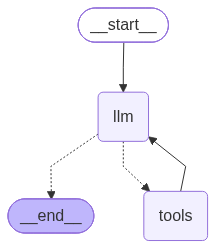

In [60]:
@tool_decorator
def write_todos(
    todos: List[Todo],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Escreve ou atualiza a lista de tarefas do planejamento da viagem.

    Use no início da tarefa, para planejar antes de agir, e de novo sempre que
    concluir um passo ou perceber que o plano precisa mudar. Cada item tem
    'descricao' e 'status' ('pendente', 'em_andamento' ou 'concluida').
    """
    resumo = ", ".join(f"{t['descricao']} [{t['status']}]" for t in todos)

    return Command(update={
        "todos": todos,
        "messages": [ToolMessage(
            content=f"Lista de tarefas atualizada com {len(todos)} itens: {resumo}",
            tool_call_id=tool_call_id,
        )],
    })

CONTEUDO_SKILL = open(CAMINHO_SKILL, encoding="utf-8").read()

SYSTEM_COORDENADOR = f"""Você é o coordenador de um agente de planejamento de viagem.

A tarefa é longa e tem muitos passos. Além das tools do cenário, você gerencia o próprio
trabalho com estas ferramentas:

- write_todos: escreve e atualiza a sua lista de tarefas.
- ls, read_file, write_file: listam, leem e gravam os arquivos do plano da viagem.

PROCEDIMENTO
1. Antes de agir, chame write_todos com o plano completo, um item por etapa.
2. Marque o item como em_andamento antes de executá-lo, e chame write_todos de novo assim que
   ele terminar.
3. Execute uma etapa por vez, na ordem do plano.
4. Todo resultado longo — roteiro, orçamento, comparações, guia final — vai para arquivo com
   write_file. Na conversa fica apenas a frase que diz o que foi gravado e onde.
5. Quando precisar de um resultado já produzido, recupere-o com read_file em vez de recalcular
   ou repetir o conteúdo.
6. Ao final, releia com read_file os arquivos relevantes e escreva a resposta ao viajante.

REGRAS
- Nunca marque como concluída uma tarefa que não foi executada.
- Se a execução revelar algo que muda o plano, reescreva a lista de tarefas.
- Nunca despeje o conteúdo integral de um arquivo na conversa.
- Respeite as restrições do cenário. Quando não for possível respeitá-las, registre a ressalva
  no arquivo, em vez de silenciar o problema.

CENÁRIO DA VIAGEM
{json.dumps(CENARIO, ensure_ascii=False, indent=2)}

SKILL DISPONÍVEL — siga este procedimento sempre que for montar o roteiro de um dia:
{CONTEUDO_SKILL}
"""

TOOLS_COORDENADOR = [write_todos, ls, read_file, write_file]
MAPA_TOOLS_COORDENADOR = {t.name: t for t in TOOLS_COORDENADOR}
TOOLS_COORDENADOR_COM_ESTADO = set(TOOLS_ARQUIVO_COM_ESTADO)  # ls e read_file leem o estado

llm_coordenador = llm.bind_tools(TOOLS_COORDENADOR)

# Limite explícito de passos: cada rodada de raciocínio é um AIMessage com tool_calls.
# Atingido o teto, o grafo encerra em vez de girar indefinidamente.
MAX_PASSOS_COORDENADOR = 12

def no_llm_coordenador(state: EstadoViagem) -> Dict[str, Any]:
    """Decide o próximo passo: responder ao viajante ou chamar tools."""
    mensagens = [SystemMessage(content=SYSTEM_COORDENADOR)] + state["messages"]
    return {"messages": [llm_coordenador.invoke(mensagens)]}

def no_tools_coordenador(state: EstadoViagem) -> Dict[str, Any]:
    """Executa as tools pedidas pelo LLM e recolhe as atualizações de estado."""
    ultima = state["messages"][-1]
    atualizacoes: Dict[str, Any] = {"messages": [], "files": {}}

    for chamada in ultima.tool_calls:
        nome = chamada["name"]

        if nome not in MAPA_TOOLS_COORDENADOR:
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro: tool '{nome}' não existe. Disponíveis: {', '.join(MAPA_TOOLS_COORDENADOR)}",
                tool_call_id=chamada["id"],
            ))
            continue

        # Tools com InjectedState recebem o estado dentro de 'args'; tools com
        # InjectedToolCallId leem o id do próprio ToolCall, por isso passamos ele inteiro.
        chamada_completa = dict(chamada)
        if nome in TOOLS_COORDENADOR_COM_ESTADO:
            chamada_completa["args"] = {**chamada["args"], "state": state}

        try:
            resultado = MAPA_TOOLS_COORDENADOR[nome].invoke(chamada_completa)
        except Exception as erro:  # o agente precisa ver o erro para poder se corrigir
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro ao executar '{nome}': {erro}",
                tool_call_id=chamada["id"],
            ))
            continue

        if isinstance(resultado, Command):
            for campo, valor in resultado.update.items():
                if campo == "messages":
                    atualizacoes["messages"].extend(valor)
                elif campo == "files":
                    atualizacoes["files"].update(valor)
                else:
                    atualizacoes[campo] = valor
        else:
            # Invocada com um ToolCall completo, a tool já devolve uma ToolMessage pronta.
            atualizacoes["messages"].append(resultado)

    return atualizacoes

def rotear_coordenador(state: EstadoViagem) -> Literal["tools", "__end__"]:
    """Segue para as tools, encerra na resposta final ou no limite de passos."""
    ultima = state["messages"][-1]

    if not getattr(ultima, "tool_calls", None):
        return END

    passos = sum(1 for m in state["messages"] if isinstance(m, AIMessage) and m.tool_calls)
    if passos >= MAX_PASSOS_COORDENADOR:
        return END

    return "tools"


builder = StateGraph(EstadoViagem)
builder.add_node("llm", no_llm_coordenador)
builder.add_node("tools", no_tools_coordenador)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", rotear_coordenador, {"tools": "tools", END: END})
builder.add_edge("tools", "llm")

coordenador = builder.compile()
display_graph(coordenador)

### Verificação — Tarefa 3

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [61]:
T = "Tarefa 3 — sistema de arquivos, skill e coordenador"

verificar(T, "EstadoViagem tem os campos esperados",
          {"messages", "todos", "cenario"}.issubset(set(EstadoViagem.__annotations__)),
          str(set(EstadoViagem.__annotations__)))

estado = {"files": {"/destinos.md": "Buenos Aires"}}
verificar(T, "ls lista os arquivos", "/destinos.md" in ls.invoke({"state": estado}))
verificar(T, "read_file lê um arquivo existente",
          read_file.invoke({"caminho": "/destinos.md", "state": estado}) == "Buenos Aires")
verificar(T, "read_file avisa quando o arquivo não existe",
          "erro" in read_file.invoke({"caminho": "/nao_existe.md", "state": estado}).lower())

cmd = write_file.invoke({"name": "write_file", "args": {"caminho": "/x.md", "conteudo": "abc"},
                         "id": "c1", "type": "tool_call"})
verificar(T, "write_file devolve Command", isinstance(cmd, Command))
verificar(T, "write_file grava no campo files", cmd.update.get("files") == {"/x.md": "abc"}, str(cmd.update))

caminho_skill = "skills/montar-dia-de-roteiro.md"
verificar(T, "arquivo da skill foi criado", os.path.exists(caminho_skill))

skill = open(caminho_skill, encoding="utf-8").read() if os.path.exists(caminho_skill) else ""
verificar(T, "skill tem frontmatter com name", "name:" in skill)
verificar(T, "skill tem frontmatter com description", "description:" in skill)
verificar(T, "skill trata a restrição de mobilidade", "mobilidade" in skill.lower())
verificar(T, "skill trata o feriado de 15/10", "feriado" in skill.lower() or "15" in skill)
verificar(T, "skill tem corpo substantivo", len(skill) > 400, f"{len(skill)} caracteres")

cmd = write_todos.invoke({"name": "write_todos",
                          "args": {"todos": [{"descricao": "Escolher destino", "status": "pendente"}]},
                          "id": "c1", "type": "tool_call"})
verificar(T, "write_todos devolve Command", isinstance(cmd, Command))
verificar(T, "write_todos atualiza o campo todos", len(cmd.update.get("todos", [])) == 1, str(cmd.update))

verificar(T, "prompt de sistema carrega o conteúdo da skill",
          any(t in SYSTEM_COORDENADOR.lower() for t in ["mobilidade", "roteiro", "proximidade"]))
verificar(T, "prompt prescreve o uso de write_todos", "write_todos" in SYSTEM_COORDENADOR)
verificar(T, "coordenador é um grafo compilado", isinstance(coordenador, CompiledStateGraph))


[OK]     EstadoViagem tem os campos esperados

[OK]     ls lista os arquivos

[OK]     read_file lê um arquivo existente

[OK]     read_file avisa quando o arquivo não existe

[OK]     write_file devolve Command

...

[OK]     write_todos devolve Command

[OK]     write_todos atualiza o campo todos

[OK]     prompt de sistema carrega o conteúdo da skill

[OK]     prompt prescreve o uso de write_todos

[OK]     coordenador é um grafo compilado

# Tarefa 4 — Subagente de Orçamento com ReWOO *(25%)*

Este subagente calcula o orçamento da viagem para um destino dado, e usa **ReWOO**.

ReWOO é a escolha certa aqui porque todas as consultas são **independentes e conhecidas de antemão**:
passagem, hospedagem, alimentação e transporte local não dependem umas das outras. Um único planejamento,
execução com substituição de variáveis, e uma síntese. É o padrão mais barato em número de chamadas de LLM.

## 5.1 O planejador

Um nó que produz, em **uma única chamada de LLM**, a lista completa de passos com variáveis:

```text
Plano: buscar o preço da passagem para o destino
#E1 = consultar_voo[Buenos Aires]
Plano: buscar a hospedagem acessível mais barata
#E2 = consultar_hospedagem[Buenos Aires]
Plano: somar o orçamento com os valores obtidos
#E3 = somar_orcamento[#E1, #E2]
```

Use `with_structured_output` com um modelo Pydantic — não faça parsing de texto livre.

## 5.2 O executor

Percorre os passos na ordem, **substituindo as variáveis** `#En` pelos resultados já obtidos, e chama a tool
correspondente. Sem chamada de LLM aqui.

## 5.3 O solver

Uma chamada final de LLM que sintetiza os resultados em um orçamento comentado, e grava em
`/orcamento.md` pelo `write_file`.

## 5.4 A tool de delegação

**`delegar_orcamento(destino, state, tool_call_id)`** — roda o subagente em contexto próprio e devolve ao
coordenador apenas o resumo, com os arquivos gravados. O histórico interno **não** volta.

Você precisará das tools `consultar_voo` e `consultar_hospedagem`, que devem ler `CATALOGO_VOOS`,
`CATALOGO_HOSPEDAGENS` e `CUSTOS_DIARIOS_BRL`. Implemente-as também.

In [62]:
@tool_decorator
def consultar_voo(destino: str) -> str:
    """
    Consulta preço, duração e escalas do voo de ida e volta para o trabalho, no catálogo fixo
    """
    infos = CATALOGO_VOOS.get(destino)
    if infos is None:
        return json.dumps(
            {"erro": "destino_invalido", "destino_disponiveis": list(CATALOGO_VOOS)}, ensure_ascii=False
        )
    return json.dumps({"destino": destino, **infos}, ensure_ascii=False)

@tool_decorator
def consultar_hospedagem(destino: str) -> str:
    """
    Consulta opções de hospedagem e custo diários (alimentação, transporte local) do destino.
    """
    opcoes = CATALOGO_HOSPEDAGENS.get(destino, [])
    custos = CUSTOS_DIARIOS_BRL.get(destino, {})

    return json.dumps({"destino": destino, "opcoes": opcoes, "custos_diarios": custos}, ensure_ascii=False)

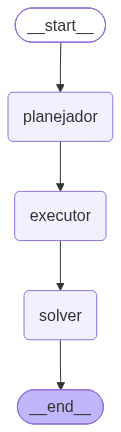

In [63]:
import re


class ArgumentoOrcamento(BaseModel):
    chave: str = Field(description="Nome do argumento da tool, ex: 'destino'.")
    valor: str = Field(
        description=(
            "Valor do argumento: um literal (ex: 'Buenos Aires', '2') ou uma referência a um "
            "passo anterior (ex: '#E1' para o resultado inteiro, ou \"#E1['campo']\" para um campo específico)."
        )
    )


class PassoOrcamento(BaseModel):
    plano: str = Field(
        description="Descrição em linguagem natural do objetivo desse passo"
    )
    variavel: str = Field(
        description="Nome da variável produzida por este passo, exemplo: E1, E2, E3"
    )
    tool: str = Field(description="Nome da tool a ser chamada neste passo.")
    argumentos: List[ArgumentoOrcamento] = Field(
        description="Lista de argumentos da tool, cada um com 'chave' (nome do parâmetro) e 'valor'."
    )


class PlanoOrcamento(BaseModel):
    passos: List[PassoOrcamento] = Field(
        description="Sequência completa de passos do plano de orçamento com ReWOO"
    )


class EstadoOrcamento(EstadoViagem):
    plano_orcamento: List[Dict[str, Any]]
    resultados_orcamento: Dict[str, Any]


@tool_decorator
def montar_itens_orcamento(
    voo: Dict[str, Any], hospedagem: Dict[str, Any], dias: int, noites: int, viajantes: int
) -> str:
    """
    Monta os itens de orçamento (passagem, hospedagem, alimentação, transporte local) a partir dos
    dados já consultados de voo e hospedagem, e da duração/número de viajantes da viagem.

    Escolhe a opção de hospedagem mais barata entre as acessíveis (ou entre todas, se nenhuma acessível).
    Retorno: lista de itens no formato [{"categoria": str, "valor_brl": float}, ...].
    """
    dias, noites, viajantes = int(dias), int(noites), int(viajantes)
    opcoes = hospedagem.get("opcoes", [])
    acessiveis = [o for o in opcoes if o.get("acessivel")]
    escolhida = (
        min(acessiveis or opcoes, key=lambda o: o.get("diaria_brl", float("inf")))
        if opcoes
        else {}
    )
    custos_diarios = hospedagem.get("custos_diarios", {})

    itens = [
        {"categoria": "passagem", "valor_brl": voo.get("preco_brl", 0) * viajantes},
        {"categoria": "hospedagem", "valor_brl": escolhida.get("diaria_brl", 0) * noites},
        {
            "categoria": "alimentacao",
            "valor_brl": custos_diarios.get("alimentacao", 0) * dias * viajantes,
        },
        {
            "categoria": "transporte_local",
            "valor_brl": custos_diarios.get("transporte_local", 0) * dias * viajantes,
        },
    ]
    return json.dumps(itens, ensure_ascii=False)


tools_por_nome_orcamento = {
    "consultar_voo": consultar_voo,
    "consultar_hospedagem": consultar_hospedagem,
    "calcular_dias": calcular_dias,
    "montar_itens_orcamento": montar_itens_orcamento,
    "somar_orcamento": somar_orcamento,
}


FERRAMENTAS_ORCAMENTO_TEXTO = """
- consultar_voo(destino: str): retorna {"destino", "preco_brl", ...} do voo de ida e volta.
- consultar_hospedagem(destino: str): retorna {"destino", "opcoes": [...], "custos_diarios": {...}}.
- calcular_dias(data_inicio: str, data_fim: str): retorna {"dias": N, "noites": N-1}.
- montar_itens_orcamento(voo, hospedagem, dias, noites, viajantes): monta os itens de orçamento já
  categorizados (passagem, hospedagem, alimentacao, transporte_local), escolhendo a hospedagem mais barata.
- somar_orcamento(itens): soma os itens e agrupa por categoria, retorna {"total_brl", "por_categoria"}.
"""


def _extrair_destino(mensagens: List[BaseMessage], cenario: Dict[str, Any]) -> str:
    texto = " ".join(str(m.content) for m in mensagens if isinstance(m, HumanMessage))
    for candidato in cenario.get("candidatos", []):
        if candidato in texto:
            return candidato
    return cenario.get("candidatos", [""])[0]


SYSTEM_PLANEJADOR = f"""Você é o planejador de um subagente de orçamento de viagem, seguindo o padrão ReWOO.
Gere, em uma única resposta, o plano COMPLETO de passos necessários para calcular o orçamento do destino
pedido, sem executar nenhuma tool você mesmo. O plano referencia resultados futuros por variáveis
(#E1, #E2, ...), que só serão substituídas por valores reais durante a execução.

Tools disponíveis:
{FERRAMENTAS_ORCAMENTO_TEXTO}

Cada passo tem uma lista de argumentos, cada argumento é um par chave/valor. Regras estritas:
1. O valor pode ser um literal (número ou texto), por exemplo: chave="destino", valor="Buenos Aires".
   NUNCA escreva expressões, fórmulas ou código como valor.
2. O valor pode referenciar o resultado inteiro de um passo anterior, como "#E1".
3. O valor pode referenciar um campo específico do resultado de um passo anterior,
   usando a sintaxe "#E1['campo']", por exemplo "#E3['dias']".
4. Nunca invente um campo que não esteja descrito na lista de tools acima.

Produza exatamente estes cinco passos, nesta ordem, nomeando as variáveis E1 a E5:
- #E1 = consultar_voo(destino=<destino pedido>)
- #E2 = consultar_hospedagem(destino=<destino pedido>)
- #E3 = calcular_dias(data_inicio=<data de ida>, data_fim=<data de volta>)
- #E4 = montar_itens_orcamento(voo=#E1, hospedagem=#E2, dias=#E3['dias'], noites=#E3['noites'], viajantes=<número de viajantes>)
- #E5 = somar_orcamento(itens=#E4)
"""


REFERENCIA_ORCAMENTO_RE = re.compile(r"^(#E\d+)(?:\[['\"]?([\w]+)['\"]?\])?$")


def resolver_valor_orcamento(valor: str, evidencias: Dict[str, Any]) -> Any:
    """Resolve uma string de argumento que pode ser um literal, uma referência inteira
    (ex: "#E1") ou uma referência a um campo específico (ex: "#E3['dias']")."""
    match = REFERENCIA_ORCAMENTO_RE.match(valor.strip())

    if not match:
        return valor  # valor literal (número ou texto), devolvido como está

    variavel, campo = match.group(1)[1:], match.group(2)  # remove o "#" de "#E1"

    if variavel not in evidencias:
        return valor  # referência a um passo inexistente: mantém como literal e deixa a tool reclamar

    bruto = evidencias[variavel]

    try:
        dado = json.loads(bruto) if isinstance(bruto, str) else bruto
    except (json.JSONDecodeError, TypeError):
        return bruto  # não era JSON (ex: mensagem de erro em texto simples)

    if campo is None:
        return dado

    if isinstance(dado, dict) and campo in dado:
        return dado[campo]

    return dado  # campo pedido não existe: devolve o dado bruto para a tool acusar o problema


def resolver_argumentos_orcamento(argumentos: List[Dict[str, str]], evidencias: Dict[str, Any]) -> Dict[str, Any]:
    resolvidos = {}
    for arg in argumentos:
        chave, valor = arg["chave"], arg["valor"]
        if isinstance(valor, str) and valor.strip().startswith("#E"):
            resolvidos[chave] = resolver_valor_orcamento(valor, evidencias)
        else:
            resolvidos[chave] = valor
    return resolvidos


def no_planejador(state: EstadoOrcamento, max_tentativas: int = 3) -> Dict[str, Any]:
    """
    Nó planejador do ReWOO: uma única chamada de LLM produz o plano completo, com variáveis
    (#E1, #E2, ...) que só serão resolvidas na execução.
    """

    cenario = state["cenario"]
    destino = _extrair_destino(state["messages"], cenario)

    tarefa = (
        f"Destino a orçar: {destino}.\n"
        f"Data de ida: {cenario['data_ida']}.\n"
        f"Data de volta: {cenario['data_volta']}.\n"
        f"Número de viajantes: {cenario.get('viajantes', 1)}."
    )

    llm_estruturado = llm.with_structured_output(PlanoOrcamento)
    mensagens = [SystemMessage(content=SYSTEM_PLANEJADOR), HumanMessage(content=tarefa)]

    ultimo_erro = None

    for tentativa in range(1, max_tentativas + 1):
        try:
            plano = llm_estruturado.invoke(mensagens)
        except Exception as exc:
            # Falha de rede, rate limit, ou erro de parsing pontual: tentamos de novo
            # em vez de deixar o grafo inteiro quebrar na primeira falha transitória.
            ultimo_erro = exc
            continue

        if plano is not None and plano.passos:
            texto_plano = "\n".join(
                f"Plano: {p.plano}\n#{p.variavel} = {p.tool}["
                + ", ".join(f"{a.chave}={a.valor}" for a in p.argumentos)
                + "]"
                for p in plano.passos
            )
            return {
                "plano_orcamento": [p.model_dump() for p in plano.passos],
                "messages": [AIMessage(content=texto_plano)],
            }

        ultimo_erro = "o modelo retornou um plano vazio ou inválido"

    raise RuntimeError(
        f"Não foi possível gerar um plano de orçamento válido após {max_tentativas} tentativas. "
        f"Último erro: {ultimo_erro}"
    )


def no_executor(state: EstadoOrcamento) -> Dict[str, Any]:
    """
    Nó executor (worker) do ReWOO: percorre o plano e chama as tools, resolvendo as referências
    #En para os resultados já obtidos, sem nenhuma chamada de LLM.
    """

    evidencias: Dict[str, Any] = dict(state.get("resultados_orcamento", {}))

    for etapa in state.get("plano_orcamento", []):
        variavel = etapa["variavel"]
        tool_name = etapa["tool"]
        argumentos = resolver_argumentos_orcamento(etapa["argumentos"], evidencias)

        if tool_name not in tools_por_nome_orcamento:
            resultado = json.dumps({"erro": "tool_desconhecida", "tool": tool_name}, ensure_ascii=False)
        else:
            try:
                resultado = tools_por_nome_orcamento[tool_name].invoke(argumentos)
            except Exception as exc:
                # Falha ao executar um passo não deve derrubar o grafo inteiro: registramos o
                # erro como evidência, e o solver pode lidar com a lacuna na resposta final.
                resultado = json.dumps(
                    {
                        "erro": "falha_ao_executar_tool",
                        "tool": tool_name,
                        "argumentos": argumentos,
                        "detalhe": str(exc),
                    },
                    ensure_ascii=False,
                )

        evidencias[variavel] = resultado

    return {"resultados_orcamento": evidencias}


def no_solver(state: EstadoOrcamento) -> Dict[str, Any]:
    """
    Nó solver do ReWOO: uma única chamada de LLM sintetiza os resultados e grava /orcamento.md
    """

    resultados = state.get("resultados_orcamento", {})
    cenario = state["cenario"]
    destino = _extrair_destino(state["messages"], cenario)
    evidencias_texto = "\n".join(f"{variavel}: {valor}" for variavel, valor in resultados.items())

    resposta = llm.invoke(
        [
            SystemMessage(
                content="Você sintetiza o orçamento de uma viagem a partir das evidências já coletadas. " \
                "Escreva um parecer curto em markdown dizendo se o total cabe no orçamento disponível " \
                "e destacando os valores por categoria."
            ),
            HumanMessage(content=(
                f"Destino: {destino}\n"
                f"Orçamento total disponível: R$ {cenario['orcamento_total_brl']:.2f}\n"
                f"Evidências coletadas:\n{evidencias_texto}"
            )),
        ]
    )

    conteudo_md = (
        f"# Orçamento - {destino}\n\n{resposta.content}\n\n"
        f"## Dados brutos\n\n```json\n{evidencias_texto}\n```\n"
    )

    cmd_arquivo = write_file.invoke({
        "name": "write_file",
        "args": {"caminho": "/orcamento.md", "conteudo": conteudo_md, "state": state},
        "id": "orcamentos-solver",
        "type": "tool_call"
    })

    return {
        "files": cmd_arquivo.update.get("files", {}),
        "messages": [resposta]
    }

grafo_orcamento = StateGraph(EstadoOrcamento)

grafo_orcamento.add_node("planejador", no_planejador)
grafo_orcamento.add_node("executor", no_executor)
grafo_orcamento.add_node("solver", no_solver)

grafo_orcamento.add_edge(START, "planejador")
grafo_orcamento.add_edge("planejador", "executor")
grafo_orcamento.add_edge("executor", "solver")
grafo_orcamento.add_edge("solver", END)

subagente_orcamento = grafo_orcamento.compile()
display_graph(subagente_orcamento)

In [64]:
@tool_decorator
def delegar_orcamento(destino: str, state: Dict[str, Any], tool_call_id: str = "stub") -> Command:
    """
    Delega o cálculo do orçamento para `destino` ao subagente_orcamento, em contexto isolado.
    """

    estado_inicial = EstadoOrcamento = {
        "messages": [HumanMessage(content=f"Calcule o orçamento para {destino}")],
        "todos": [],
        "files": dict(state.get("files") or {}),
        "cenario": state.get("cenario", CENARIO),
        "plano_orcamento": [],
        "resultados_orcamento": {},
    }

    resultado = subagente_orcamento.invoke(estado_inicial)

    arquivos = resultado.get("files") or {}
    resumo = next(
        (m.content for m in reversed(resultado["messages"]) if isinstance(m, AIMessage)),
        "Orçamento calculado.",
    )

    return Command(update={
        "files": arquivos,
        "messages": [
            ToolMessage(
                content=f"Orçamento para {destino} calculado e gravado em /orcamento.md. \n\n{resumo}",
                tool_call_id=tool_call_id
            )
        ],
    })

### Verificação — Tarefa 4

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [65]:
T = "Tarefa 4 — subagente ReWOO"

r = json.loads(consultar_voo.invoke({"destino": "Buenos Aires"}))
verificar(T, "consultar_voo devolve o preço do catálogo", abs(r.get("preco_brl", 0) - 1850.0) < 0.01, str(r))

r = json.loads(consultar_hospedagem.invoke({"destino": "Santiago"}))
verificar(T, "consultar_hospedagem devolve opções", len(r.get("opcoes", r if isinstance(r, list) else [])) >= 1, str(r))

verificar(T, "subagente de orçamento é um grafo compilado", isinstance(subagente_orcamento, CompiledStateGraph))

nos = set(subagente_orcamento.get_graph().nodes)
verificar(T, "grafo tem os três papéis do ReWOO",
          sum(1 for n in nos if any(p in n.lower() for p in ["plan", "exec", "solv", "work"])) >= 3, str(nos))

resultado = subagente_orcamento.invoke({
    "messages": [HumanMessage(content="Calcule o orçamento para Buenos Aires.")],
    "todos": [], "files": {}, "cenario": CENARIO,
})

chamadas_llm = sum(1 for m in resultado["messages"] if isinstance(m, AIMessage))
verificar(T, "ReWOO usa poucas chamadas de LLM (<= 4)", chamadas_llm <= 4, f"{chamadas_llm} chamadas")
verificar(T, "subagente gravou /orcamento.md", "/orcamento.md" in (resultado.get("files") or {}),
          str(list((resultado.get('files') or {}).keys())))

cmd = delegar_orcamento.invoke({
    "name": "delegar_orcamento",
    "args": {"destino": "Buenos Aires", "state": {"files": {}, "cenario": CENARIO}},
    "id": "c1",
    "type": "tool_call",
})
verificar(T, "delegar_orcamento devolve Command", isinstance(cmd, Command))
verificar(T, "delegação devolve arquivos ao coordenador", "/orcamento.md" in (cmd.update.get("files") or {}))
verificar(T, "delegação devolve UMA mensagem ao coordenador", len(cmd.update.get("messages", [])) == 1,
          "o histórico interno do subagente não deve voltar")

[OK]     consultar_voo devolve o preço do catálogo

[OK]     consultar_hospedagem devolve opções

[OK]     subagente de orçamento é um grafo compilado

[OK]     grafo tem os três papéis do ReWOO

[OK]     ReWOO usa poucas chamadas de LLM (<= 4)

[OK]     subagente gravou /orcamento.md

[OK]     delegar_orcamento devolve Command

[OK]     delegação devolve arquivos ao coordenador

[OK]     delegação devolve UMA mensagem ao coordenador

# Tarefa 5 — Subagente de Destino com Tree of Thoughts *(25%)*

Este subagente escolhe **um** dos três destinos candidatos, e usa **Tree of Thoughts**.

ToT é a escolha certa aqui porque o problema é de **seleção entre alternativas**: gerar candidatos, avaliar
cada um e podar os piores. Não há sequência de ações a planejar — há um espaço de opções a explorar.

## 6.1 A árvore

A árvore tem dois níveis e **seis folhas**:

```text
                        raiz
        ┌────────────────┼────────────────┐
   Buenos Aires      Santiago        Montevidéu
     ┌────┴────┐     ┌────┴────┐     ┌────┴────┐
   gastro.  natureza gastro. natureza gastro. natureza
```

Nível 1: os três destinos candidatos do cenário.
Nível 2: para cada destino, **duas abordagens de viagem** — uma com ênfase em gastronomia e museus, outra com
ênfase em natureza urbana.

## 6.2 Os três nós

**Gerador** — produz as seis folhas, cada uma com uma descrição curta da viagem proposta.

**Avaliador** — pontua cada folha de 0 a 10 em quatro critérios, usando saída estruturada:
custo estimado, clima na janela de datas, aderência aos interesses, e **acessibilidade** (a restrição de
mobilidade reduzida). Use as tools MCP da Tarefa 2 para o clima, e as tools de catálogo da Tarefa 5 para o
custo — a avaliação não pode ser puro chute do modelo.

**Podador** — descarta as folhas abaixo da mediana, escolhe a melhor entre as restantes, e grava a decisão
com a justificativa em `/destinos.md`.

## 6.3 A tool de delegação

**`delegar_destino(state, tool_call_id)`** — mesmo padrão da Tarefa 5.

In [66]:
class FolhaDestino(BaseModel):
    destino: str = Field(description="Nome do destino candidato, deve bater com um dos candidatos do cenário.")
    abordagem: Literal["gastronomia_e_museus", "natureza_urbana"] = Field(
        description="Ênfase da abordagem de viagem para esta folha."
    )
    descricao: str = Field(
        description="Descrição curta (2-3 frases) da viagem proposta para este destino nesta abordagem."
    )


class ArvoreDestinos(BaseModel):
    folhas: List[FolhaDestino] = Field(
        description=(
            "As seis folhas da árvore: para cada um dos três destinos candidatos, uma folha com abordagem "
            "'gastronomia_e_museus' e outra com abordagem 'natureza_urbana'."
        )
    )


gerador_de_destinos = llm.with_structured_output(ArvoreDestinos)


class AvaliacaoDestino(BaseModel):
    destino: str = Field(description="Nome do destino avaliado, deve bater com uma das folhas.")
    abordagem: str = Field(description="Abordagem avaliada, deve bater com uma das folhas.")
    aderencia_interesses: float = Field(
        description="Nota de 0 a 10 para o quanto a proposta cobre os interesses do cenário."
    )
    acessibilidade: float = Field(
        description="Nota de 0 a 10 para o quanto a proposta respeita a restrição de mobilidade reduzida."
    )
    justificativa: str = Field(description="Justificativa curta para as notas, em uma ou duas frases.")


class AvaliacaoDeFolhas(BaseModel):
    avaliacoes: List[AvaliacaoDestino] = Field(
        description="Uma avaliação para cada uma das seis folhas geradas."
    )


avaliador_de_destinos = llm.with_structured_output(AvaliacaoDeFolhas)

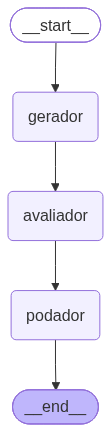

In [67]:
import asyncio
import concurrent.futures


def _run_async(coro):
    """Roda uma coroutine a partir de código síncrono, mesmo dentro de um notebook com event loop
    já ativo (ex: Jupyter). Se não houver loop rodando nesta thread, usa asyncio.run diretamente;
    senão, roda a coroutine em uma thread própria para não colidir com o loop já em execução."""
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(coro)
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        return executor.submit(asyncio.run, coro).result()


def _custo_total_destino(destino: str, cenario: Dict[str, Any]) -> float:
    """Reaproveita as tools da Tarefa 4 (ReWOO) para obter um custo total real por destino."""
    voo = json.loads(consultar_voo.invoke({"destino": destino}))
    hospedagem = json.loads(consultar_hospedagem.invoke({"destino": destino}))
    dias_info = json.loads(calcular_dias.invoke({
        "data_inicio": cenario["data_ida"], "data_fim": cenario["data_volta"],
    }))
    itens = json.loads(montar_itens_orcamento.invoke({
        "voo": voo,
        "hospedagem": hospedagem,
        "dias": dias_info["dias"],
        "noites": dias_info["noites"],
        "viajantes": cenario.get("viajantes", 1),
    }))
    total = json.loads(somar_orcamento.invoke({"itens": itens}))
    return total["total_brl"]


def _clima_destino(destino: str, cenario: Dict[str, Any]) -> Dict[str, float]:
    """Consulta a tool MCP de clima da Tarefa 2 para a janela de datas do cenário. Em caso de falha
    (servidor indisponível, event loop incompatível, etc.), devolve um clima neutro em vez de
    derrubar a avaliação inteira."""
    latitude, longitude = COORDENADAS[destino]
    argumentos = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": cenario["data_ida"],
        "end_date": cenario["data_volta"],
    }
    try:
        resposta = _run_async(client_mcp.call_tool("weather_forecast", argumentos))
        diario = json.loads(resposta)["daily"]
        temperatura_media = sum(diario["temperature_2m_max"]) / len(diario["temperature_2m_max"])
        precipitacao_total = sum(diario["precipitation_sum"])
    except Exception:
        temperatura_media, precipitacao_total = 25.0, 0.0

    return {"temperatura_media": temperatura_media, "precipitacao_total_mm": precipitacao_total}


def _normalizar_custo(custos: Dict[str, float]) -> Dict[str, float]:
    """Converte custos absolutos em notas de 0 a 10: o destino mais barato recebe a nota mais alta."""
    minimo, maximo = min(custos.values()), max(custos.values())
    if maximo == minimo:
        return {destino: 10.0 for destino in custos}
    return {
        destino: round(10 - 8 * (valor - minimo) / (maximo - minimo), 1)
        for destino, valor in custos.items()
    }


def _normalizar_clima(climas: Dict[str, Dict[str, float]]) -> Dict[str, float]:
    """Converte temperatura média e precipitação total em nota de 0 a 10: penaliza temperaturas fora
    de uma faixa confortável (18-28°C, centrada em 23°C) e volume de chuva."""
    notas = {}
    for destino, dados in climas.items():
        penalidade_temperatura = max(0.0, abs(dados["temperatura_media"] - 23.0) - 5.0) * 0.4
        penalidade_chuva = min(dados["precipitacao_total_mm"], 50.0) * 0.08
        notas[destino] = round(max(0.0, min(10.0, 10 - penalidade_temperatura - penalidade_chuva)), 1)
    return notas


class EstadoDestino(EstadoViagem):
    folhas_destino: List[Dict[str, Any]]
    avaliacoes_destino: List[Dict[str, Any]]
    destino_escolhido: Optional[str]


SYSTEM_GERADOR_DESTINO = """Gere exatamente seis folhas para a árvore de decisão do destino da viagem:
para cada um dos três destinos candidatos do cenário, duas abordagens de viagem distintas — uma com ênfase
em gastronomia e museus ('gastronomia_e_museus'), outra com ênfase em natureza urbana ('natureza_urbana').

Cada folha deve ter uma descrição curta (2-3 frases) da viagem proposta para aquele destino naquela
abordagem, considerando os interesses e restrições do cenário."""


def no_gerador(state: EstadoDestino) -> Dict[str, Any]:
    """
    Nó gerador do ToT: uma única chamada de LLM produz as seis folhas (branching).
    """

    cenario = state["cenario"]
    contexto = (
        f"Destinos candidatos: {', '.join(cenario['candidatos'])}\n"
        f"Interesses: {', '.join(cenario.get('interesses', []))}\n"
        f"Restrições: {'; '.join(cenario.get('restricoes', []))}"
    )

    resposta = gerador_de_destinos.invoke([
        SystemMessage(content=SYSTEM_GERADOR_DESTINO),
        HumanMessage(content=contexto),
    ])

    return {"folhas_destino": [f.model_dump() for f in resposta.folhas]}


SYSTEM_AVALIADOR_DESTINO = """Avalie cada folha (destino + abordagem) em duas dimensões, notas de 0 a 10:
- aderencia_interesses: o quanto a proposta cobre os interesses do cenário.
- acessibilidade: o quanto a proposta respeita a restrição de mobilidade reduzida do grupo — trajetos a pé
  longos ou atrações sem acessibilidade devem reduzir a nota. Considere também o feriado local, se impactar
  a proposta.

Justifique cada nota em uma ou duas frases. Custo e clima já foram calculados separadamente — não os avalie."""


def no_avaliador(state: EstadoDestino) -> Dict[str, Any]:
    """
    Nó avaliador do ToT: pontua cada folha em quatro critérios. Custo e clima vêm de tools reais
    (Tarefa 4 e MCP da Tarefa 2, respectivamente) — só aderência aos interesses e acessibilidade vêm
    de julgamento do LLM, para que a avaliação não seja puro chute do modelo.
    """

    cenario = state["cenario"]
    folhas = state.get("folhas_destino", [])

    custos = {destino: _custo_total_destino(destino, cenario) for destino in cenario["candidatos"]}
    climas = {destino: _clima_destino(destino, cenario) for destino in cenario["candidatos"]}
    notas_custo = _normalizar_custo(custos)
    notas_clima = _normalizar_clima(climas)

    folhas_texto = "\n".join(f"- {f['destino']} ({f['abordagem']}): {f['descricao']}" for f in folhas)
    contexto = (
        f"Interesses do cenário: {', '.join(cenario.get('interesses', []))}\n"
        f"Restrições do cenário: {'; '.join(cenario.get('restricoes', []))}\n\n"
        f"Folhas candidatas:\n{folhas_texto}"
    )

    resposta = avaliador_de_destinos.invoke([
        SystemMessage(content=SYSTEM_AVALIADOR_DESTINO),
        HumanMessage(content=contexto),
    ])

    avaliacoes = []
    for avaliacao in resposta.avaliacoes:
        nota_custo = notas_custo.get(avaliacao.destino, 5.0)
        nota_clima = notas_clima.get(avaliacao.destino, 5.0)
        score = (nota_custo + nota_clima + avaliacao.aderencia_interesses + avaliacao.acessibilidade) / 4

        avaliacoes.append({
            "destino": avaliacao.destino,
            "abordagem": avaliacao.abordagem,
            "custo_estimado": nota_custo,
            "clima": nota_clima,
            "aderencia_interesses": avaliacao.aderencia_interesses,
            "acessibilidade": avaliacao.acessibilidade,
            "justificativa": avaliacao.justificativa,
            "score": round(score, 2),
            "custo_total_brl": custos.get(avaliacao.destino),
        })

    return {"avaliacoes_destino": avaliacoes}


def no_podador(state: EstadoDestino) -> Dict[str, Any]:
    """
    Nó podador do ToT: descarta as folhas abaixo da mediana, escolhe a melhor entre as restantes,
    e grava a decisão com a justificativa em /destinos.md.
    """

    avaliacoes = state.get("avaliacoes_destino", [])

    scores_ordenados = sorted(a["score"] for a in avaliacoes)
    meio = len(scores_ordenados) // 2
    if len(scores_ordenados) % 2 == 1:
        mediana = scores_ordenados[meio]
    else:
        mediana = (scores_ordenados[meio - 1] + scores_ordenados[meio]) / 2

    sobreviventes = [a for a in avaliacoes if a["score"] >= mediana] or avaliacoes
    melhor = max(sobreviventes, key=lambda a: a["score"])

    linhas = ["# Escolha de destino (Tree of Thoughts)\n", "\n## Folhas avaliadas\n"]
    for avaliacao in sorted(avaliacoes, key=lambda a: -a["score"]):
        podada = " — **podada, abaixo da mediana**" if avaliacao["score"] < mediana else ""
        linhas.append(
            f"\n- **{avaliacao['destino']} — {avaliacao['abordagem']}**{podada}: score {avaliacao['score']:.2f} "
            f"(custo {avaliacao['custo_estimado']:.1f}, clima {avaliacao['clima']:.1f}, "
            f"interesses {avaliacao['aderencia_interesses']:.1f}, "
            f"acessibilidade {avaliacao['acessibilidade']:.1f})\n"
            f"  - {avaliacao['justificativa']}\n"
        )

    linhas.append(f"\n## Destino escolhido: {melhor['destino']} ({melhor['abordagem']})\n\n")
    linhas.append(
        f"Score {melhor['score']:.2f}, custo total estimado de R$ {melhor['custo_total_brl']:.2f}. "
        f"{melhor['justificativa']}\n"
    )

    conteudo_md = "".join(linhas)

    cmd_arquivo = write_file.invoke({
        "name": "write_file",
        "args": {"caminho": "/destinos.md", "conteudo": conteudo_md, "state": state},
        "id": "destinos-podador",
        "type": "tool_call"
    })

    return {
        "destino_escolhido": melhor["destino"],
        "files": cmd_arquivo.update.get("files", {}),
        "messages": [
            AIMessage(
                content=f"Destino escolhido: {melhor['destino']} ({melhor['abordagem']}), score {melhor['score']:.2f}."
            )
        ],
    }


grafo_destino = StateGraph(EstadoDestino)

grafo_destino.add_node("gerador", no_gerador)
grafo_destino.add_node("avaliador", no_avaliador)
grafo_destino.add_node("podador", no_podador)

grafo_destino.add_edge(START, "gerador")
grafo_destino.add_edge("gerador", "avaliador")
grafo_destino.add_edge("avaliador", "podador")
grafo_destino.add_edge("podador", END)

subagente_destino = grafo_destino.compile()
display_graph(subagente_destino)

In [68]:
@tool_decorator
def delegar_destino(state: Dict[str, Any], tool_call_id: str = "stub") -> Command:
    """
    Delega a escolha do destino da viagem ao subagente_destino, em contexto isolado.
    """

    estado_inicial: EstadoDestino = {
        "messages": [HumanMessage(content="Escolha o destino da viagem.")],
        "todos": [],
        "files": dict(state.get("files") or {}),
        "cenario": state.get("cenario", CENARIO),
        "folhas_destino": [],
        "avaliacoes_destino": [],
        "destino_escolhido": None,
    }

    resultado = subagente_destino.invoke(estado_inicial)

    arquivos = resultado.get("files") or {}
    resumo = next(
        (m.content for m in reversed(resultado["messages"]) if isinstance(m, AIMessage)),
        "Destino escolhido.",
    )

    return Command(update={
        "files": arquivos,
        "messages": [
            ToolMessage(
                content=f"Destino escolhido e registrado em /destinos.md. \n\n{resumo}",
                tool_call_id=tool_call_id
            )
        ],
    })

### Verificação — Tarefa 5

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [69]:
T = "Tarefa 5 — subagente ToT"

verificar(T, "subagente de destino é um grafo compilado", isinstance(subagente_destino, CompiledStateGraph))

nos = set(subagente_destino.get_graph().nodes)
verificar(T, "grafo tem os três papéis do ToT",
          sum(1 for n in nos if any(p in n.lower() for p in ["ger", "aval", "pod", "prun", "select"])) >= 3,
          str(nos))

resultado = subagente_destino.invoke({
    "messages": [HumanMessage(content="Escolha o destino da viagem.")],
    "todos": [], "files": {}, "cenario": CENARIO,
})

verificar(T, "subagente gravou /destinos.md", "/destinos.md" in (resultado.get("files") or {}),
          str(list((resultado.get('files') or {}).keys())))

conteudo = (resultado.get("files") or {}).get("/destinos.md", "")
verificar(T, "arquivo cita os três candidatos",
          all(c in conteudo for c in CENARIO["candidatos"]), "as folhas avaliadas devem aparecer")
verificar(T, "arquivo registra um destino escolhido",
          any(c in conteudo for c in CENARIO["candidatos"]) and len(conteudo) > 200,
          f"{len(conteudo)} caracteres")
verificar(T, "avaliação considerou acessibilidade",
          "acess" in conteudo.lower() or "mobilidade" in conteudo.lower())

cmd = delegar_destino.invoke({"name": "delegar_destino",
                              "args": {"state": {"files": {}, "cenario": CENARIO}},
                              "id": "c1", "type": "tool_call"})
verificar(T, "delegar_destino devolve Command", isinstance(cmd, Command))
verificar(T, "delegação devolve UMA mensagem ao coordenador", len(cmd.update.get("messages", [])) == 1)

[OK]     subagente de destino é um grafo compilado

[OK]     grafo tem os três papéis do ToT

[OK]     subagente gravou /destinos.md

[OK]     arquivo cita os três candidatos

[OK]     arquivo registra um destino escolhido

[OK]     avaliação considerou acessibilidade

[OK]     delegar_destino devolve Command

[OK]     delegação devolve UMA mensagem ao coordenador

# Tarefa 6 — Integração *(10%)*

Amarre tudo em um único deep agent e execute a tarefa completa.

O coordenador deve ter acesso a: `write_todos`, `ls`, `read_file`, `write_file`, as tools locais da Tarefa 1,
as tools MCP da Tarefa 2, e as duas tools de delegação. Compile em **`agente_viagem`**.

A tarefa a executar:

> Planeje a viagem descrita no cenário. Escolha o destino, calcule o orçamento e produza um guia final com a
> recomendação, o resumo de custos e as ressalvas sobre as restrições. Grave o guia em `/guia_final.md`.

Depois de executar, imprima o traço em três partes: a **lista de tarefas final**, o **sistema de arquivos**
com o tamanho de cada arquivo, e a **sequência de chamadas de tool**.

tools do agente:
[
    'write_todos',
    'ls',
    'read_file',
    'write_file',
    'calcular_dias',
    'somar_orcamento',
    'tempo_deslocamento',
    'validar_datas_roteiro',
    'weather_forecast',
    'geocoding',
    'delegar_destino',
    'delegar_orcamento'
]

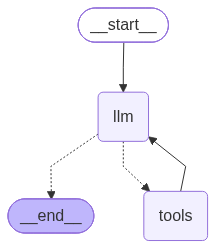

In [70]:
# ---------------------------------------------------------------------------
# 6.1 — Montagem do agente completo
#
# O coordenador da Tarefa 3, agora com as tools locais (T1), as tools MCP (T2) e as
# duas tools de delegação (T4 e T5).
# ---------------------------------------------------------------------------

# Das 17 tools do servidor MCP, o coordenador recebe as duas que o cenário usa.
TOOLS_MCP_AGENTE = [t for t in tools_mcp if t.name in {"geocoding", "weather_forecast"}]

TOOLS_AGENTE = [
    write_todos,                                                                # plano
    ls, read_file, write_file,                                                  # arquivos (T3)
    calcular_dias, somar_orcamento, tempo_deslocamento, validar_datas_roteiro,  # locais (T1)
    *TOOLS_MCP_AGENTE,                                                          # MCP (T2)
    delegar_destino, delegar_orcamento,                                         # delegação (T5, T4)
]
MAPA_TOOLS_AGENTE = {t.name: t for t in TOOLS_AGENTE}

NOMES_MCP_AGENTE = {t.name for t in TOOLS_MCP_AGENTE}
# Tools que leem o estado do grafo.
TOOLS_AGENTE_COM_ESTADO = {"ls", "read_file", "delegar_destino", "delegar_orcamento"}
# As tools de delegação montam a própria ToolMessage: precisam do id da chamada, senão a
# resposta não casa com o tool_call e o provedor rejeita a mensagem.
TOOLS_AGENTE_COM_TOOL_CALL_ID = {"delegar_destino", "delegar_orcamento"}

SYSTEM_AGENTE = SYSTEM_COORDENADOR + """
DELEGAÇÃO
- delegar_destino: escolhe o destino entre os candidatos e grava /destinos.md. Faça isso primeiro.
- delegar_orcamento: calcula o orçamento do destino escolhido e grava /orcamento.md.
- Não refaça o trabalho dos subagentes; leia com read_file o que eles gravaram.

ENTREGA FINAL
- Grave o guia em /guia_final.md com write_file, contendo a recomendação de destino, o resumo de
  custos e as ressalvas sobre mobilidade reduzida e sobre o feriado de 15/10.
- Antes de responder ao viajante, chame write_todos uma última vez com todos os itens 'concluida'.
"""

llm_agente = llm.bind_tools(TOOLS_AGENTE)

MAX_PASSOS_AGENTE = 16


def no_llm_agente(state: EstadoViagem) -> Dict[str, Any]:
    """Decide o próximo passo: responder ao viajante ou chamar tools."""
    mensagens = [SystemMessage(content=SYSTEM_AGENTE)] + state["messages"]
    return {"messages": [llm_agente.invoke(mensagens)]}


def no_tools_agente(state: EstadoViagem) -> Dict[str, Any]:
    """Executa as tools pedidas pelo LLM e recolhe as atualizações de estado."""
    ultima = state["messages"][-1]
    atualizacoes: Dict[str, Any] = {"messages": [], "files": {}}

    for chamada in ultima.tool_calls:
        nome = chamada["name"]

        if nome not in MAPA_TOOLS_AGENTE:
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro: tool '{nome}' não existe. Disponíveis: {', '.join(MAPA_TOOLS_AGENTE)}",
                tool_call_id=chamada["id"],
            ))
            continue

        try:
            if nome in NOMES_MCP_AGENTE:
                # as tools MCP são assíncronas; passam pelo ClientMCP da Tarefa 2, que
                # mantém o cache e o fallback, e a coroutine roda pelo _run_async
                texto = _run_async(client_mcp.call_tool(nome, chamada["args"]))
                resultado = ToolMessage(content=str(texto), tool_call_id=chamada["id"])
            else:
                extras: Dict[str, Any] = {}
                if nome in TOOLS_AGENTE_COM_ESTADO:
                    extras["state"] = state
                if nome in TOOLS_AGENTE_COM_TOOL_CALL_ID:
                    extras["tool_call_id"] = chamada["id"]

                chamada_completa = dict(chamada)
                chamada_completa["args"] = {**chamada["args"], **extras}
                resultado = MAPA_TOOLS_AGENTE[nome].invoke(chamada_completa)

        except Exception as erro:  # o agente precisa ver o erro para poder se corrigir
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro ao executar '{nome}': {erro}",
                tool_call_id=chamada["id"],
            ))
            continue

        if isinstance(resultado, Command):
            for campo, valor in resultado.update.items():
                if campo == "messages":
                    atualizacoes["messages"].extend(valor)
                elif campo == "files":
                    atualizacoes["files"].update(valor)
                else:
                    atualizacoes[campo] = valor
        else:
            atualizacoes["messages"].append(resultado)

    return atualizacoes


def rotear_agente(state: EstadoViagem) -> Literal["tools", "__end__"]:
    """Segue para as tools, encerra na resposta final ou no limite de passos."""
    ultima = state["messages"][-1]

    if not getattr(ultima, "tool_calls", None):
        return END

    passos = sum(1 for m in state["messages"] if isinstance(m, AIMessage) and m.tool_calls)
    if passos >= MAX_PASSOS_AGENTE:
        return END

    return "tools"


builder = StateGraph(EstadoViagem)
builder.add_node("llm", no_llm_agente)
builder.add_node("tools", no_tools_agente)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", rotear_agente, {"tools": "tools", END: END})
builder.add_edge("tools", "llm")

agente_viagem = builder.compile()

print("tools do agente:", [t.name for t in TOOLS_AGENTE])
display_graph(agente_viagem)

In [71]:
TAREFA_VIAGEM = (
    "Planeje a viagem descrita no cenário. Escolha o destino, calcule o orçamento e produza um guia "
    "final com a recomendação, o resumo de custos e as ressalvas sobre as restrições. "
    "Grave o guia em /guia_final.md."
)

execucao = agente_viagem.invoke({
    "messages": [HumanMessage(content=TAREFA_VIAGEM)],
    "todos": [], "files": {}, "cenario": CENARIO,
})

arquivos_finais = execucao.get("files") or {}

print("=== 1. lista de tarefas final ===")
for item in execucao.get("todos") or []:
    # sem colchetes: o print do rich trataria "[concluida]" como marcação e a apagaria
    print(f"  {item['status']:12} {item['descricao']}")

print("\n=== 2. sistema de arquivos ===")
for caminho, conteudo in sorted(arquivos_finais.items()):
    print(f"  {caminho:18} {len(conteudo):6} caracteres")

print("\n=== 3. sequência de chamadas de tool ===")
rodada = 0
for mensagem in execucao["messages"]:
    if isinstance(mensagem, AIMessage) and mensagem.tool_calls:
        rodada += 1
        for chamada in mensagem.tool_calls:
            print(f"  rodada {rodada:2}  {chamada['name']}")

contexto = contar_tokens_aproximado(execucao["messages"])
total_arquivos = sum(len(c) for c in arquivos_finais.values())
print(f"\ndescarregamento de contexto: ~{contexto} tokens na conversa, "
      f"{total_arquivos} caracteres em arquivo")

print("\n=== /guia_final.md ===")
print(Markdown(arquivos_finais.get("/guia_final.md", "(guia não gravado)")))

=== 1. lista de tarefas final ===

concluida    Escolher o destino entre os candidatos: Buenos Aires, Santiago, Montevidéu

concluida    Calcular o orçamento do destino escolhido

concluida    Produzir o guia final com a recomendação, resumo de custos e ressalvas sobre as restrições

=== 2. sistema de arquivos ===

...

rodada  7  write_file

rodada  8  write_todos

descarregamento de contexto: ~2791 tokens na conversa, 4637 caracteres em arquivo

=== /guia_final.md ===

Guia Final da Viagem a Montevidéu                                         

Destino Escolhido                                                                                                  

Montevidéu (natureza urbana)                                                                                       

Resumo de Custos                                                                                                   

 • Passagem: R$ 4.100,00                                                                                           
 • Hospedagem: R$ 2.450,00                                                                                         
 • Alimentação: R$ 3.040,00                                                                                        
 • Transporte Local: R$ 880,00                                                                                     

Total da Viagem: R$ 10.470,00                                                                                      

O total da viagem está dentro do orçamento disponível de R$ 12.000,00, restando um saldo de R$ 1.530,00. Portanto, 
a viagem é viável financeiramente.                                                                                 

Considerações sobre as Restrições                                                                                  

 • Mobilidade Reduzida: Montevidéu oferece acessibilidade em várias atrações, mas é importante verificar a         
   acessibilidade de cada atividade planejada.                                                                     
 • Feriado Local em 15/10: No dia 15 de outubro, museus e comércio estarão majoritariamente fechados. Portanto,    
   recomenda-se dedicar esse dia a atividades ao ar livre, como parques e praças, que são acessíveis e agradáveis. 

Conclusão                                                                                                          

Montevidéu é uma excelente escolha para a viagem, oferecendo uma boa experiência de natureza urbana, com           
acessibilidade e opções de lazer. No entanto, é importante planejar as atividades de acordo com as restrições      
mencionadas.

### Verificação — Tarefa 6

**Não modifique esta célula.** Ela só deve ser executada, para checar sua solução.


In [72]:
T = "Tarefa 6 — integração"

verificar(T, "agente_viagem é um grafo compilado", isinstance(agente_viagem, CompiledStateGraph))

final = agente_viagem.invoke({
    "messages": [HumanMessage(content=(
        "Planeje a viagem descrita no cenário. Escolha o destino, calcule o orçamento e produza um guia "
        "final com a recomendação, o resumo de custos e as ressalvas sobre as restrições. "
        "Grave o guia em /guia_final.md."
    ))],
    "todos": [], "files": {}, "cenario": CENARIO,
})

arquivos = final.get("files") or {}
verificar(T, "o agente produziu o guia final", "/guia_final.md" in arquivos, str(list(arquivos)))
verificar(T, "o agente delegou a escolha de destino", "/destinos.md" in arquivos)
verificar(T, "o agente delegou o orçamento", "/orcamento.md" in arquivos)
verificar(T, "o agente escreveu uma lista de tarefas", len(final.get("todos") or []) >= 3,
          str(final.get("todos")))
verificar(T, "todas as tarefas foram encerradas",
          all(t.get("status") == "concluida" for t in (final.get("todos") or [{}])),
          "verifique se o agente marcou o progresso")

tokens_ctx = contar_tokens_aproximado(final["messages"])
total_arquivos = sum(len(c) for c in arquivos.values())
verificar(T, "houve descarregamento de contexto", total_arquivos > tokens_ctx,
          f"contexto ~{tokens_ctx} tokens, arquivos {total_arquivos} caracteres")

resumo_verificacoes()

[OK]     agente_viagem é um grafo compilado

[OK]     o agente produziu o guia final

[OK]     o agente delegou a escolha de destino

[OK]     o agente delegou o orçamento

[OK]     o agente escreveu uma lista de tarefas

...

Tarefa 2 — integração MCP          3/3 critérios

Tarefa 3 — sistema de arquivos, skill e coordenador 17/17 critérios

Tarefa 4 — subagente ReWOO         9/9 critérios

Tarefa 5 — subagente ToT           8/8 critérios

Tarefa 6 — integração              7/7 critérios

# 8. Checklist de entrega

Antes de entregar, verifique:

1. Todas as células foram executadas **na ordem**, e as saídas estão salvas no notebook.
2. A célula `resumo_verificacoes()` ao final da Tarefa 6 foi executada e a saída está visível.
3. O arquivo `skills/montar-dia-de-roteiro.md` está junto do notebook, assim como a configuração do
   servidor MCP usado na Tarefa 2 (comando/argumentos), se relevante para reproduzir sua execução.
4. As questões da análise crítica (Seção 7) estão respondidas.
5. As especificações escritas da Seção 8 (Plan-and-Execute e Reflection) estão preenchidas.
6. Nenhum valor do dicionário `CENARIO` foi alterado.
7. O arquivo segue o padrão de nome descrito na Seção 0.3 — Submissão.
